# Logistic Perceptron

In this chapter, we study the logistic perceptron and derive its training objective step by step.

This chapter is fundamental for building an understanding of Deep Learning because it introduces several ideas that reappear throughout neural networks like optimization-based training, differentiable loss functions, output activations, and the connection between a model output and the objective used to train it.

The central theme is that model outputs cannot be interpreted from their numerical values alone. Their meaning depends on the surrounding modeling choices: the output function, the assumptions we make about the target variable, and the objective used during training.

The logistic perceptron is a particularly clean example of how these pieces fit together. In this specific setting, a linear decision score is transformed into an output that can be interpreted as a class probability, and the model is trained with an objective that matches this interpretation.

We will use this perspective to understand how the logistic perceptron produces probabilistically meaningful predictions, why Binary Cross-Entropy is a suitable training objective, and how this connects to likelihood and Negative Log-Likelihood.

Later models and tasks may use different output types and different objectives. The goal of this chapter is therefore to build an intuition for how model outputs, assumptions, and training objectives interact in a concrete and manageable setting.

## Prerequisites

Required prior knowledge from the chapters:

- Perceptron
- Gradient Descent

**Objective of this chapter:**

- explain how the logistic perceptron extends the classical perceptron
- interpret the sigmoid output as a class probability under a Bernoulli assumption
- understand why Binary Cross-Entropy is a suitable loss for binary classification
- derive the simple error signal $p_i-y_i$ for sigmoid combined with BCE
- visualize probability surfaces and decision boundaries
- explain the difference between predicted probabilities and hard class decisions
- understand likelihood, log-likelihood, and Negative Log-Likelihood in the Bernoulli setting
- explain why mean BCE is equivalent to mean Negative Log-Likelihood

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from matplotlib.ticker import ScalarFormatter
import beginner.perceptron.perceptron as perceptron
import beginner.gradient_descent.gradient_descent as grad_desc

In [2]:
rng = np.random.default_rng(53)

## Review: Activation Function

Since the model only differs in the use of the sigmoid function as the output activation, we will briefly review it first.


**Sigmoid:**
$$ f(x)=\frac{1}{1+e^{-x}} $$

You can see at a glance that:
- The value range is in **(0,1)**
- Monotonically increasing
- For large **|x|**, the value approaches **0** or **1**
- Continuously differentiable

The output of the sigmoid function can be given semantics. For binary classification, this means:
- $\sigma(z) < 0.5$ → Class **0**
- $\sigma(z) >= 0.5$ → Class **1**


**Step function:**

You can see at a glance:
- Values can only be **0** or **1**
- **x = 0** is not defined
- even if differentiable, slope = 0 -> no usable gradient -> no information content


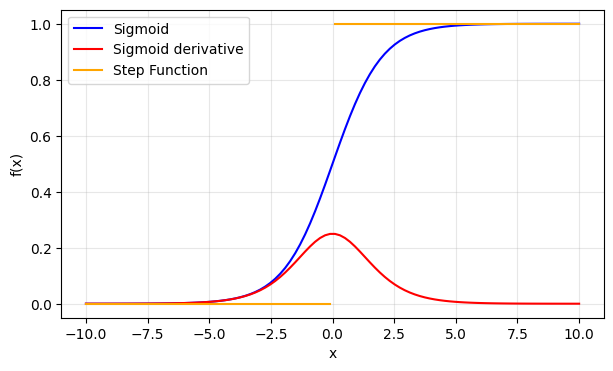

In [3]:
x = np.linspace(-10, 10, 100)
fig1, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, perceptron.sigmoid(x), c="blue", label="Sigmoid")
ax.plot(x, perceptron.sigmoid_derivative(x), c="red", label="Sigmoid derivative")
ax.plot(x[x < 0], perceptron.step_function(x[x < 0]), c="orange", label="Step Function")
ax.plot(x[x >= 0], perceptron.step_function(x[x >= 0]), c="orange")

ax.grid(alpha=0.3)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend();

## Data Generation

First, we generate a linearly separable synthetic dataset with a fictional decision boundary. Data points below this boundary are assigned to class 0, while data points above the boundary are assigned to class 1.

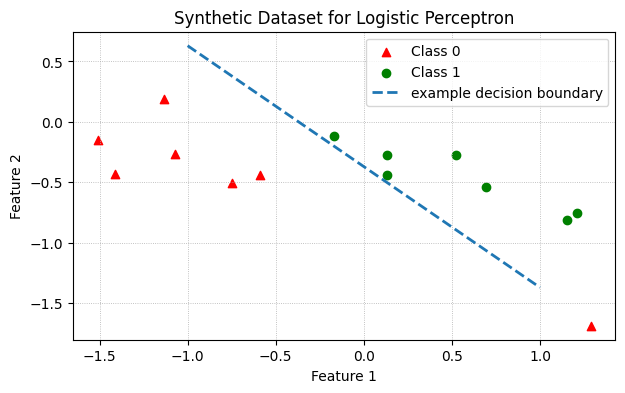

In [4]:
X, y = make_classification(
    n_samples=14,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.5,
    flip_y=0.0,
    random_state=53
)
y_train = np.asarray(y).reshape(-1, 1)

def visualize_data(X: np.ndarray, y:np.ndarray, title:str):
    fig, ax = plt.subplots(figsize=(7,4))
    ax.scatter(X[y==0,0], X[y==0,1], color="red", marker="^", label="Class 0")
    ax.scatter(X[y==1,0], X[y==1,1], color="green", marker="o", label="Class 1")    
    ax.legend()
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(title)
    ax.grid(ls=":", linewidth=0.6)
    return fig, ax

fig2, ax = visualize_data(X,y,"Synthetic Dataset for Logistic Perceptron")
perceptron.ex_boundary_helper(ax,-0.37)

# Training

We now train the logistic perceptron using the error-counting approach from the Perceptron chapter and inspect the model output for each data point.

**Dev Diary:**  
Although our training method expects `y` to have shape `(n_samples, 1)`, I accidentally passed it with shape `(14,)`. I was aware of both shapes, but still overlooked it. A small mistake, but an annoying bug hunt.


Solution in Epoch 48


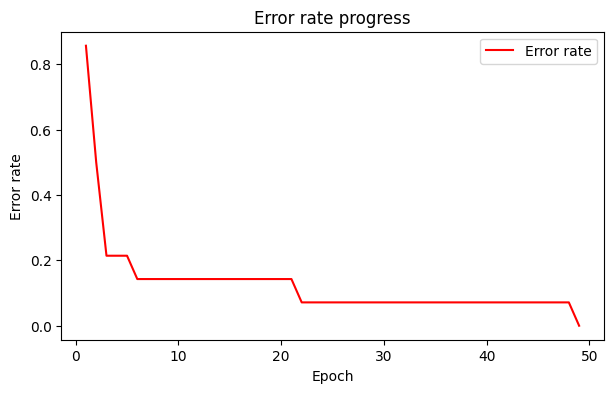

In [5]:
model = perceptron.Perceptron(X.shape[1], perceptron.sigmoid)
error_history,_ = model.train(X, y_train, lr=0.1, error_prints=False, epochs=100)
fig3, ax = perceptron.visualize_training(error_history)

## Helper Functions

To visualize decision boundaries throughout the rest of the notebook, we will now define two helper functions.

In [6]:
def create_2d_grid(X: np.ndarray, steps: int = 100, padding: float = 0.2):
    """
    Creates a 2D feature grid based on the range of the input data.

    Args:
        X (np.ndarray):
            Feature matrix of shape (n_samples, 2).
        steps (int):
            Number of grid points per axis.
        padding (float):
            Additional margin added around the data range.

    Returns:
        x1_grid, x2_grid:
            Meshgrid arrays of shape (steps, steps).
        X_feature_grid:
            Flattened feature grid of shape (steps * steps, 2).
    """
    assert X.shape[1] == 2, "This function only supports 2D input data."

    x1_min, x1_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x2_min, x2_max = X[:, 1].min() - padding, X[:, 1].max() + padding

    x1 = np.linspace(x1_min, x1_max, steps)
    x2 = np.linspace(x2_min, x2_max, steps)

    x1_grid, x2_grid = np.meshgrid(x1, x2)
    X_feature_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]

    return x1_grid, x2_grid, X_feature_grid


def visualize_decision_boundary(
    model: "perceptron.Perceptron",
    X: np.ndarray,
    y: np.ndarray,
    description: str,
    annotation: bool = True,
    max_annotations: int | None = None,
    padding: float = 0.2,
    steps: int = 100
):
    """
    Visualizes the learned decision boundary of a perceptron.
    Args:
        model:
            Trained model
        X (np.ndarray):
            Feature matrix of shape (n_samples, 2).
        y (np.ndarray):
            labels corresponding to X
        description (str):
            Title
        padding (float):
            Additional margin added around the data range.
        annotation (bool):
            If True, displays the model output at each data point.
        max_annotations (int): 
            set the number of max annotations in figure
        steps (int):
            Number of grid points per axis
        

    Returns:
        fig, ax:
            Matplotlib figure and axes objects.
    """
    x1_grid, x2_grid, X_feature_grid = create_2d_grid(
        X=X,
        steps=steps,
        padding=padding
    )
    y_vis = model.forward(X_feature_grid).reshape(steps,-1)
    fig, ax = visualize_data(X,y,description)
    cf = ax.contourf(x1_grid, x2_grid, y_vis, levels=10, cmap='coolwarm', alpha=0.6, zorder=0)
    prediction = model.forward(X).reshape(-1)
    if annotation:
        rng = np.random.default_rng(53)
        if max_annotations is None:
            max_annotations = len(y)
        n_annotations = min(max_annotations, len(X))
        annotation_idx = rng.choice(len(X), size=n_annotations, replace=False)
        for idx in annotation_idx:
            xi = X[idx]
            y_hat = prediction[idx]
            ax.annotate(
                f"{y_hat:.2f}",
                xy=(xi[0], xi[1]),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                fontsize=8,
            )
    fig.colorbar(cf, label="Prediction")
    return fig, ax

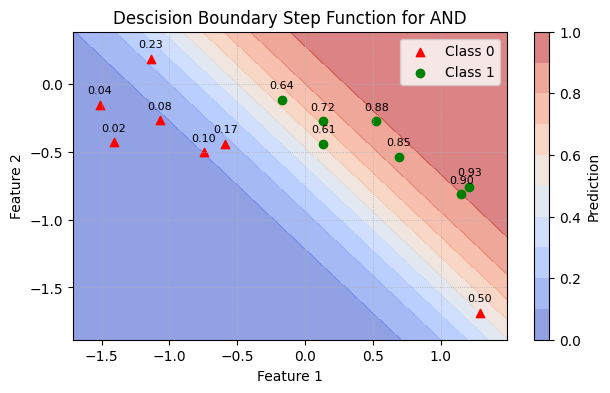

In [7]:
fig4, ax = visualize_decision_boundary(model, X, y, "Descision Boundary Step Function for AND")

## Evaluating Sigmoid with Error Counting

At this stage, the output value can be interpreted as a geometrically meaningful decision score relative to the decision boundary. High values correspond to points on the side of class 1, while low values correspond to points on the side of class 0. The closer a data point lies to the decision boundary, the closer the output is to 0.5.

## Part 1: Probabilistically Justified Predictions

In the next part, we examine how moving from rule-based learning to an optimization objective allows us to give the model output a probabilistic interpretation.

This point is important because the meaning of a model output does not come from its numerical value alone. A value between 0 and 1 is not automatically a probability. It becomes meaningful only when the output function and the training objective support this interpretation.

The goal is therefore to move from a simple decision score to a probabilistically justified prediction.

## Synthetic Dataset with Overlapping Classes

For the following sections, we will use a synthetic dataset with two features and binary target values that is not perfectly linearly separable.

As we already saw in the Perceptron chapter, this exposes a limitation of purely rule-based learning procedures such as error counting. Error counting only distinguishes between correct and incorrect predictions. For example, if the true label is $y=1$, then predictions of $p=0.51$ and $p=0.99$ would both be counted as correct after applying a threshold.

However, these two predictions are not equally informative. A prediction of $0.99$ assigns much more confidence to the observed label than a prediction of $0.51$. Our training objective should be able to take this difference into account.

We use this synthetic dataset as an observed sample. The model only sees these data points and has to learn a relationship between the features and the binary labels from this sample.

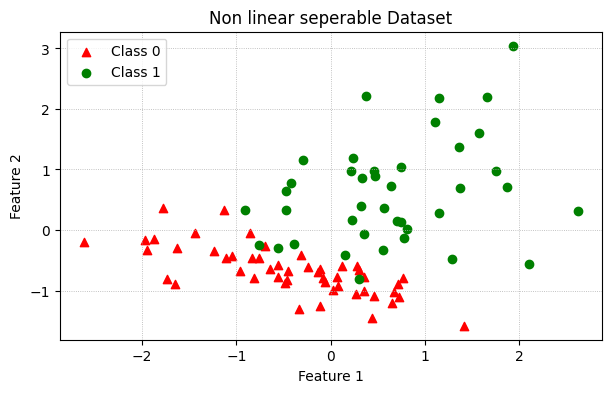

In [8]:
X, y = make_classification(
    n_samples=90,
    n_features=2,
    n_redundant=0,
    weights=[0.55, 0.45],
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.6,
    flip_y=0.0,
    random_state=51
)

fig5, ax = visualize_data(X,y,"Non linear seperable Dataset")



A quick exploration shows that there is a class imbalance. Class 1 occurs less frequently in the dataset.

In [9]:
unique, counts = np.unique(y, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": unique,
    "Absolute frequency": counts,
    "Relative frequency": (counts / len(y)).round(2)
})

class_distribution

,Class,Absolute frequency,Relative frequency
0,0,50,0.56
1,1,40,0.44


In [10]:
p_empirical = np.mean(y)

print(f"Empirical relative frequency of class 1: {p_empirical:.3f}")
print(f"Empirical relative frequency of class 0: {1 - p_empirical:.3f}")

Empirical relative frequency of class 1: 0.444
Empirical relative frequency of class 0: 0.556


## Binary Target Variables as Bernoulli Random Variables

A data point has a binary label:

**1** or **0**, **success** or **failure**

A Bernoulli random variable $Y$ is described by exactly one parameter $p$. This parameter represents the probability that the event $Y=1$ occurs. Accordingly, the probability of the opposite event $Y=0$ is $1-p$:

$$
P(Y=1)=p, \qquad P(Y=0)=1-p
$$

This changes how we view the classification problem. So far, we could think of the label in a purely deterministic way: 

A data point belongs either to one class or to the other. From the Bernoulli perspective, we now view the label as the **realization of a binary random experiment**.

An important distinction is the difference between the **observed label** and the **underlying probability**:

- The observed label is the actually realized value, so $y_i \in \{0,1\}$.
- The Bernoulli parameter describes the probability with which the event $Y=1$ occurs.

For a classification model with input features, this probability is not the same for all data points. Instead of a single global parameter $p$, we are interested in an individual conditional probability for each sample $x_i$:

$$
p_i = P(Y=1 \mid X=x_i)
$$

In practice, we do not know this probability directly. We only observe the inputs $x_i$ and their corresponding labels $y_i$. The goal of the model is therefore to estimate this unknown probability from the input features.

At this point, the difference to the relative frequency in the dataset becomes clear. The empirical frequency of class $1$ only describes how often class $1$ occurs in the observed dataset as a whole. It is a global property of the sample. The logistic perceptron, however, aims to model an individual probability $p_i$ for each data point.

## From Model Output to Class Probability

We now extend the previous model assumption with:

$$
p_i = \sigma(z_i)=\sigma(w^\top x_i+b)
$$

Under the Bernoulli model assumption, we interpret this output as an estimate of the conditional probability

$$
p_i = P(Y=1 \mid X=x_i)
$$

This does not replace the geometric interpretation of the decision score. Instead, it adds a **probabilistic meaning** to it.



## BCE as an Optimization Objective

A suitable optimization objective should evaluate how much probability the model assigns to the actually observed label.

For a single data point, the Binary Cross-Entropy is defined as:

$$
\mathrm{BCE}(y_i,p_i)
=
-\left[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

For $y_i=1$, only the following term remains:

$$
\mathrm{BCE}(1,p_i)=-\log(p_i)
$$

For $y_i=0$, only the following term remains:

$$
\mathrm{BCE}(0,p_i)=-\log(1-p_i)
$$

The two cases show that the loss depends on the probability assigned to the actually observed label. The information-theoretic interpretation of “Cross-Entropy” will be discussed in a separate chapter.

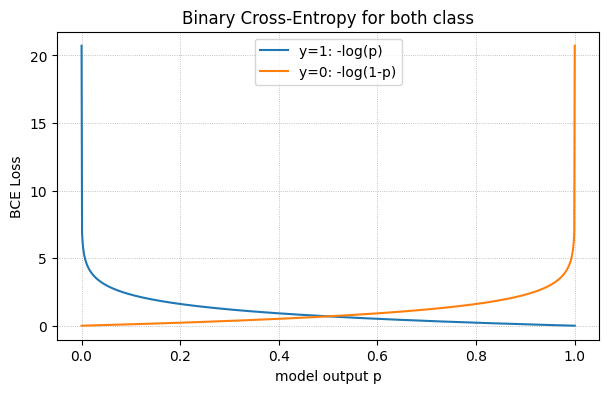

In [11]:
stability_term = 1e-9
p_values = np.linspace(stability_term, 1 - stability_term, 1000)

bce_y1 = -np.log(p_values)
bce_y0 = -np.log(1 - p_values)

fig6, ax = plt.subplots(figsize=(7, 4))

ax.plot(p_values, bce_y1, label="y=1: -log(p)")
ax.plot(p_values, bce_y0, label="y=0: -log(1-p)")

ax.set_xlabel("model output p")
ax.set_ylabel("BCE Loss")
ax.set_title("Binary Cross-Entropy for both class")
ax.legend()
ax.grid(ls=":", linewidth=0.6);

## Probability of the Observed Label and the Role of the Logarithm

Binary Cross-Entropy becomes easier to interpret when we explicitly focus on the probability of the actually observed label.

The sigmoid output $p_i$ first describes the model's predicted probability for class $1$:

$$
p_i = P(Y=1 \mid X=x_i)
$$

For evaluating a concrete data point, however, the relevant probability depends on the observed label. 
If $y_i=1$, the relevant probability is $p_i$. If $y_i=0$, the relevant probability is $1-p_i$.

Both cases can be written compactly as

$$
q_i = y_i p_i + (1-y_i)(1-p_i)
$$

Here, $q_i$ denotes the probability that the model assigns to the actually observed label. Since $y_i$ can only take the values $0$ or $1$, it acts like a switch:

- For $y_i=1$, we get $q_i=p_i$.
- For $y_i=0$, we get $q_i=1-p_i$.

Using this notation, the Binary Cross-Entropy for a single data point can be written as

$$
\mathrm{BCE}(y_i,p_i)=-\log(q_i)
$$

BCE is small when the model assigns a high probability to the observed label, and large when this probability is small.

The negative logarithm amplifies this effect. If $q_i$ is close to $1$, then approximately

$$
-\log(q_i) \approx 0
$$

The model has assigned a high probability to the observed label, so the loss is small.

If $q_i$ is close to $0$, then

$$
-\log(q_i)
$$

becomes very large. In that case, the model assigned only a very small probability to the actually observed label.

Binary Cross-Entropy therefore strongly penalizes predictions where the model assigns very little probability to the observed label. This is why it is well suited as an optimization objective for probabilistic classification.

In [12]:
examples = pd.DataFrame({
    "y": [1, 1, 1, 0, 0, 0, 1,],
    "p": [0.99, 0.50, 0.01, 0.01, 0.50, 0.99, 0.001]
})

examples["q"] = (
    examples["y"] * examples["p"] 
    + (1 - examples["y"]) * (1 - examples["p"])
)

examples["BCE"] = -np.log(examples["q"])

examples.round(4)

,y,p,q,BCE
0,1,0.990,0.990,0.0101
1,1,0.500,0.500,0.6931
2,1,0.010,0.010,4.6052
3,0,0.010,0.990,0.0101
4,0,0.500,0.500,0.6931
5,0,0.990,0.010,4.6052
6,1,0.001,0.001,6.9078


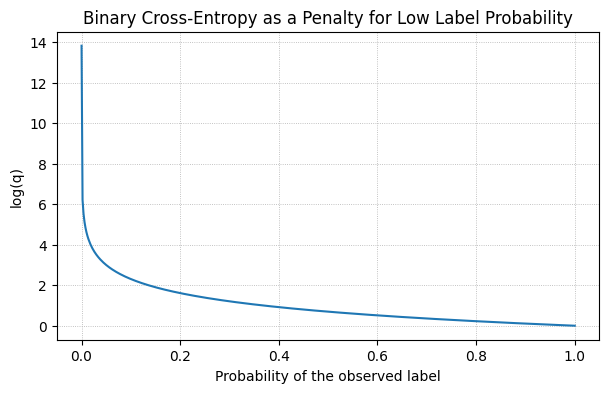

In [13]:

q_values = np.linspace(1e-6, 1, 500)
loss_values = -np.log(q_values)

fig7, ax = plt.subplots(figsize=(7, 4))

ax.plot(q_values, loss_values)

ax.set_xlabel("Probability of the observed label")
ax.set_ylabel("log(q)")
ax.set_title("Binary Cross-Entropy as a Penalty for Low Label Probability")
ax.grid(ls=":", linewidth=0.6);

## Binary Cross-Entropy over the Entire Dataset

For a dataset with $n$ observations, Binary Cross-Entropy is typically computed as the mean of the individual loss values:

$$
\mathrm{BCE}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Taking the mean ensures that the loss does not grow directly with the number of data points.

Conceptually, the mean Binary Cross-Entropy evaluates how much probability the model assigns to the observed labels on average.

In [14]:
def binary_cross_entropy(y_true: np.ndarray, p_pred: np.ndarray) -> float:
    """
    Computes the mean Binary Cross-Entropy.

    Parameters
    ----------
    y_true : np.ndarray
        Binary labels with values 0 or 1.
    p_pred : np.ndarray
        Predicted probabilities for class 1.

    Returns
    -------
    float
        Mean Binary Cross-Entropy.
    """
    y_true = y_true.flatten()
    p_pred = p_pred.flatten()
    stability_term = 1e-9

    p_pred = np.clip(p_pred, stability_term, 1 - stability_term)

    loss = -(
        y_true * np.log(p_pred)
        + (1 - y_true) * np.log(1 - p_pred)
    )

    return np.mean(loss)

## BCE as a Function of the Model Parameters

So far, we have considered Binary Cross-Entropy as a function of the observed label $y_i$ and the predicted probability $p_i$.

In the logistic perceptron, however, this probability is produced by the model parameters $w$ and $b$:

$$
p_i = \sigma(w^\top x_i + b)
$$

Therefore, the loss does not only depend on $p_i$ directly, but also indirectly on the model parameters. If we put the model equation into the Binary Cross-Entropy, we obtain for a single data point:

$$
\mathrm{BCE}(y_i,w,b)
=
-\left[
y_i \log(\sigma(w^\top x_i+b))
+
(1-y_i)\log(1-\sigma(w^\top x_i+b))
\right]
$$

For the entire dataset, we take the mean over all data points:

$$
\mathrm{BCE}(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\sigma(w^\top x_i+b))
+
(1-y_i)\log(1-\sigma(w^\top x_i+b))
\right]
$$

This turns the training of the logistic perceptron into an optimization problem:

$$
\min_{w,b} \ \mathrm{BCE}(w,b)
$$

The goal is to adjust the weights $w$ and the bias $b$ so that the mean Binary Cross-Entropy on the dataset becomes as small as possible.

This is a fundamental difference compared to a purely rule-based update. We now explicitly define a loss function and search for parameters that minimize this loss. Interested readers can find more details in the **Gradient Descent** chapter series.

## 8. Gradient for the Logistic Perceptron

This follows the same idea as in the **Gradient Descent** chapter series, but this time with Binary Cross-Entropy and an additional activation function.

Here, $p_i$ denotes the predicted probability for class $1$.

The red term $p_i-y_i$ is the error signal at the output. It arises from the combination of the BCE derivative and the sigmoid derivative.

$$
\Large
\begin{aligned}
\nabla_{w,b}\,\mathrm{BCE}
&=
\begin{bmatrix}
\dfrac{\partial\,\mathrm{BCE}}{\partial w} \\
\dfrac{\partial\,\mathrm{BCE}}{\partial b}
\end{bmatrix}
=
\frac{1}{n}
\sum_{i=1}^{n}
\begin{bmatrix}
x_i{\color{red}{(p_i-y_i)}} \\
{\color{red}{(p_i-y_i)}}
\end{bmatrix}
\\[1em]
\frac{\partial \mathrm{BCE}}{\partial w}
&=
\frac{1}{n}
\sum_{i=1}^{n}
{\color{red}{\frac{\partial \mathrm{BCE}_i}{\partial p_i}}}
\cdot
{\color{red}{\frac{\partial p_i}{\partial z_i}}}
\cdot
\frac{\partial z_i}{\partial w}
=
\frac{1}{n}
\sum_{i=1}^{n}
x_i{\color{red}{(p_i-y_i)}}
\\[0.8em]
\frac{\partial \mathrm{BCE}}{\partial b}
&=
\frac{1}{n}
\sum_{i=1}^{n}
{\color{red}{\frac{\partial \mathrm{BCE}_i}{\partial p_i}}}
\cdot
{\color{red}{\frac{\partial p_i}{\partial z_i}}}
\cdot
\frac{\partial z_i}{\partial b}
=
\frac{1}{n}
\sum_{i=1}^{n}
{\color{red}{(p_i-y_i)}}
\end{aligned}
$$

## Why Sigmoid with BCE?

In principle, any differentiable activation function with output range $(0,1)$ could be used to interpret the output as a Bernoulli parameter. 

$$
p_i = g(z_i)
$$


However, the sigmoid function is suitable because, together with Binary Cross-Entropy, it produces a very simple and interpretable derivative. For a general activation function $g$ with $p_i=g(z_i)$, we get:

$$
\frac{\partial \mathrm{BCE}}{\partial z_i}
=
\frac{p_i-y_i}{p_i(1-p_i)}
\cdot
g'(z_i)
$$

For the sigmoid function, we have:

$$
g'(z_i)=\sigma(z_i)(1-\sigma(z_i))=p_i(1-p_i)
$$

This simplifies the output error signal to:

$$
\frac{\partial \mathrm{BCE}}{\partial z_i}=p_i-y_i
$$

This simplification is not only computationally elegant, but also semantically meaningful: the learning signal is directly the difference between the predicted probability and the observed label.

Therefore, the sigmoid function is not just an transformation into the interval $(0,1)$. It fits particularly well with the Bernoulli model assumption and Binary Cross-Entropy.

# Visualizing the BCE Derivative and the Error Signal

To better understand the interaction between Binary Cross-Entropy and the sigmoid activation, we now visualize both the derivative of BCE with regard to the predicted probability $p_i$ and the resulting error signal.

We get these two cases:

- if $y_i=0$, then $p_i-y_i=p_i$
- if $y_i=1$, then $p_i-y_i=p_i-1$

The left plot shows the derivative of Binary Cross-Entropy with regard to the predicted probability $p_i$.

The right plot shows the resulting error signal

$$
p_i-y_i
$$

which happens after taking the sigmoid derivative into account. This signal is much easier to interpret:

- For $y_i=1$, the error signal is negative as long as $p_i<1$.
- For $y_i=0$, the error signal is positive as long as $p_i>0$.
- The closer the predicted probability is to the observed label, the smaller the magnitude of the error signal.

This simple error signal is exactly what we use in the next step to compute the gradients in regard to the model parameters $w$ and $b$.

In [15]:
stability_term = 1e-9
p_values = np.linspace(stability_term, 1 - stability_term, 500)

# Implementation of the formula top
d_bce_dp_y1 = (p_values - 1) / (p_values * (1 - p_values))
d_bce_dp_y0 = (p_values - 0) / (p_values * (1 - p_values))

# Error Signal after Sigmoid Derivative
# dBCE/dz = p - y
signal_y1 = p_values - 1
signal_y0 = p_values - 0

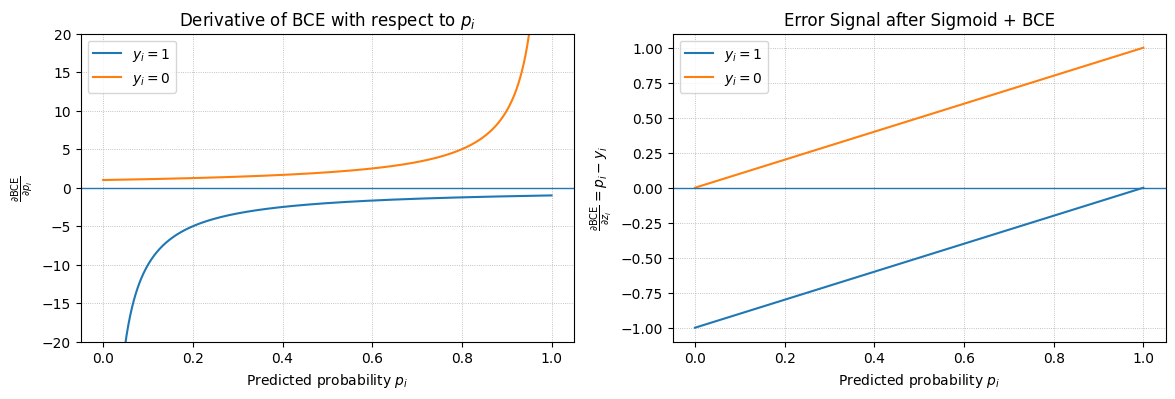

In [16]:
fig8, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Left plot: derivative of BCE with respect to p
ax1.plot(p_values, d_bce_dp_y1, label="$y_i=1$")
ax1.plot(p_values, d_bce_dp_y0, label="$y_i=0$")
ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Predicted probability $p_i$")
ax1.set_ylabel("$\\frac{\\partial \\mathrm{BCE}}{\\partial p_i}$")
ax1.set_title("Derivative of BCE with respect to $p_i$")
ax1.set_ylim(-20, 20)
ax1.legend()
ax1.grid(ls=":", linewidth=0.6)

# Right plot: error signal p - y
ax2.plot(p_values, signal_y1, label="$y_i=1$")
ax2.plot(p_values, signal_y0, label="$y_i=0$")
ax2.axhline(0, linewidth=1)
ax2.set_xlabel("Predicted probability $p_i$")
ax2.set_ylabel("$\\frac{\\partial \\mathrm{BCE}}{\\partial z_i}=p_i-y_i$")
ax2.set_title("Error Signal after Sigmoid + BCE")
ax2.legend()
ax2.grid(ls=":", linewidth=0.6)

## Interpretation of the Visualization

The visualization highlights an important difference between the BCE loss itself and the error signal that is passed back through the output.

The BCE loss can become very large when the model assigns only a very small probability to the observed label. The derivative of BCE with respect to the predicted probability $p_i$ can also become very large in these regions.

After combining BCE with the sigmoid activation, however, the local error signal at the output logit becomes much simpler. It is no longer an unbounded expression in terms of $p_i$, but the direct difference between the predicted probability and the observed label.

So the BCE loss itself is not bounded. What becomes simple and bounded is the local error signal at the output logit.

# Training
Now we can create the function for the training. For the time being, we will continue to use the full-batch gradient descent algorithm, which we are already familiar with from the chapter on **Gradient Descent**.





In [17]:
print(f"Shape X : {X.shape}, Shape y: {y.shape}")
def train(model: perceptron.Perceptron, X: np.ndarray, y: np.ndarray, lr=0.01, epochs=10000):
    """
    Trains the logistic Perceptron using full batch gd for BCE+Sigmoid

    Args:
        model Perzeptron object
        X (np.ndarray): Input data of shape (n_samples, n_features).
        y (np.ndarray): Target labels of shape (n_samples, 1) 
        lr (float): Learning rate
        epochs (int): Maximum number of training epochs.

    Returns: 
        list[float]: Mean Binary Cross-Entropy after each epoch. Initial loss is not included.
    """
    y = y.reshape(-1,1)
    loss_history = []
    for epoch in range(epochs):
        prediction = model.forward(X)
        assert prediction.shape == y.shape, "shape missmatch"
        error_signal = (prediction - y)
        model.weight = model.weight - lr * ((X.T @ error_signal)/X.shape[0])
        model.bias = model.bias - lr * np.mean(error_signal)
        prediction = model.forward(X)
        mean_loss = binary_cross_entropy(y, prediction)
        loss_history.append(mean_loss)
    return loss_history

Shape X : (90, 2), Shape y: (90,)


The model is initialised and trained as usual, and the BCE loss is plotted. For illustrative purposes and for the later part of the notebook, I have divided the training into two phases here. First, training is carried out over 10,000 epochs, followed by a further 190,000 epochs using the parameters already learned.

Start Loss: 0.88
Final Loss: 0.15


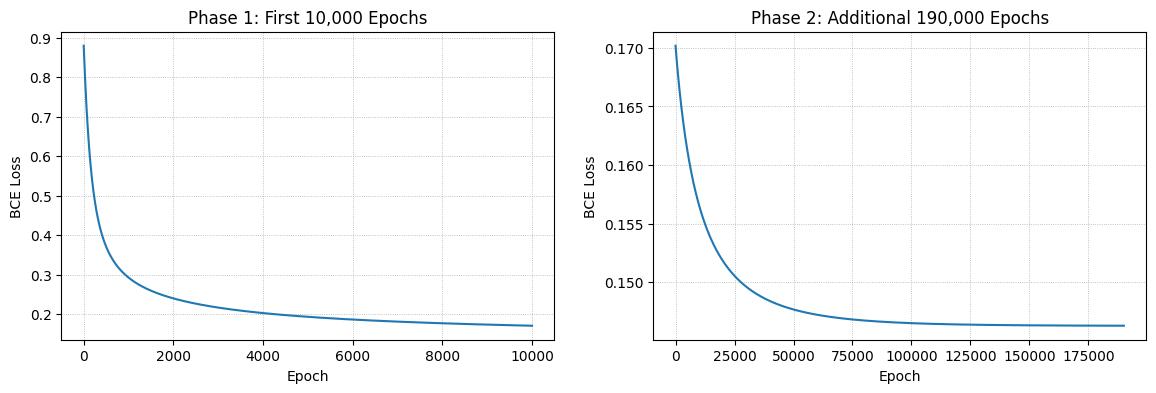

In [18]:
model = perceptron.Perceptron(X.shape[1], perceptron.sigmoid)
loss_history_1 = train(model, X, y)
loss_history_2 = train(model, X, y,epochs=190000)

fig9, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

perceptron.visualize_loss(
    loss_history_1,
    y_label="BCE Loss",
    x_label="Epoch",
    ax=ax1,
    title="Phase 1: First 10,000 Epochs"
)

perceptron.visualize_loss(
    loss_history_2,
    y_label="BCE Loss",
    x_label="Epoch",
    ax=ax2,
    title="Phase 2: Additional 190,000 Epochs"
)
print(f"Start Loss: {round(loss_history_1[0], 2)}")
print(f"Final Loss: {round(loss_history_2[-1], 2)}")

## Short Interpretation

The training shows that the mean Binary Cross-Entropy decreases continuously over the epochs. During training, the loss approaches a final value of approximately $0.15$. The parameters were adjusted so that the observed labels become more plausible under the predicted probabilities.

**Conclusion:** The model fits the training data better as training progresses.

However, we should not conclude from the initial BCE alone that the model classifies worse than random guessing. BCE evaluates predicted probabilities, not accuracy. Accuracy measures the proportion of correctly classified predictions after applying a decision threshold.

As a reference, we can consider a constant probabilistic baseline model. This model predicts the empirical frequency of class $0$ for every data point. For our sample, this is approximately $p=0.56$. The corresponding BCE is

$$
-\left[0.56\log(0.56)+0.44\log(0.44)\right]\approx 0.686.
$$

The initial training loss of approximately $0.88$ is above this baseline. This means that the randomly initialized model initially assigns, on average, less suitable probabilities to the observed labels than this constant reference model. Individual data points can contribute differently to the mean loss.

Since we only consider the training loss here, this does not yet tell us how well the model generalizes to unseen data.

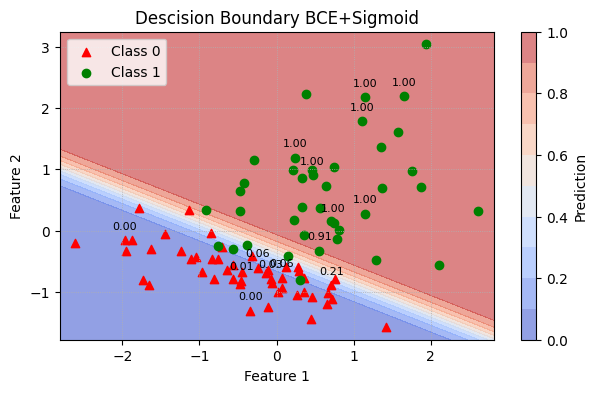

In [19]:
fig10, ax = visualize_decision_boundary(model, X, y, "Descision Boundary BCE+Sigmoid", True, 15)

## Probability Surface and Decision Boundary

The colored regions show the probability surface learned by the model.

Red regions correspond to high predicted probabilities for class $1$, while blue regions correspond to low predicted probabilities for class $1$. The lighter transition region appears where the model distinguishes less clearly between the two classes.

Using the standard threshold of $0.5$, the decision boundary is located where

$$
p(x)=0.5.
$$

Since the sigmoid function satisfies

$$
\sigma(0)=0.5,
$$

this boundary corresponds exactly to all points for which

$$
w^\top x+b=0.
$$

Therefore, the geometric interpretation is preserved. The linear score

$$
z=w^\top x+b
$$

still describes the position of a point relative to the decision boundary. Points with $z>0$ lie on the side of class $1$, while points with $z<0$ lie on the side of class $0$. The farther a point is from the decision boundary, the larger the magnitude of $z$.

The sigmoid function adds a probabilistic interpretation to this geometric view. It transforms the linear score into a probability between $0$ and $1$:

$$
p(x)=\sigma(z).
$$

As a result, points far on the side of class $1$ receive probabilities close to $1$, points far on the side of class $0$ receive probabilities close to $0$, and points close to the decision boundary receive probabilities close to $0.5$.

The probability surface therefore contains more information than the hard decision boundary alone. The boundary only shows where the predicted class would change under a chosen threshold, while the probability surface also shows how strongly the model leans toward class $1$ or class $0$.

## Converting Probabilities into Classes

The logistic perceptron does not directly output a hard class label. Instead, it outputs a predicted probability for class $1$:

$$
p_i = P(Y=1 \mid X=x_i)
$$

To turn this probability into a concrete class prediction, we use a decision threshold. The standard choice is a threshold of $0.5$:

$$
\hat y_i =
\begin{cases}
1, & \text{wenn } p_i \geq 0.5 \\
0, & \text{wenn } p_i < 0.5
\end{cases}
$$

This threshold is natural for a sigmoid output because $p_i=0.5$ corresponds to the point where both classes are equally plausible under the model.

This turns the probabilistic model output into a hard classification decision.

It is important to note that the threshold is not part of the sigmoid function itself. The sigmoid function only produces the probability. The decision threshold then specifies from which probability onward we predict class $1$.

In practical applications, this threshold does not always have to be $0.5$. Depending on the problem, it can be useful to adjust it. For example, in medical screening, a lower threshold may be chosen to reduce the number of missed positive cases. In a spam filter, a higher threshold may be useful if normal emails should rarely be classified as spam by mistake.

This process is called threshold tuning and will be revisited after the chapter on classification metrics. It should be distinguished from probability calibration. Calibration asks whether a model output such as $p=0.8$ really means that class $1$ occurs in roughly 80% of comparable cases.

In [20]:
def predict_classes(model, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """
    Converts predicted probabilities into hard class predictions.

    Args:
        model:
            Trained perceptron model with a forward method.
        X (np.ndarray):
            Input data of shape (n_samples, n_features).
        threshold (float):
            Decision threshold for predicting class 1.

    Returns:
        np.ndarray:
            Predicted class labels of shape (n_samples, 1).
    """
    probabilities = model.forward(X)
    predictions = (probabilities >= threshold).astype(int)

    return predictions

y_pred = predict_classes(model, X, threshold=0.5)

prediction_table = pd.DataFrame({
    "p_pred": model.forward(X).reshape(-1),
    "y_pred": y_pred.reshape(-1),
    "y_true": y
})

prediction_table.head(10).round(3)

,p_pred,y_pred,y_true
0,1.000,1,1
1,1.000,1,1
2,0.005,0,0
3,0.000,0,0
4,1.000,1,1
5,0.737,1,0
6,0.022,0,0
7,0.002,0,0
8,1.000,1,1
9,0.047,0,0


# Likelihood of the Observed Data

So far, we have used Binary Cross-Entropy as an optimization objective. The model was trained to assign high probabilities to the observed labels.

We now look at the same idea from a statistical perspective. For each sample $x_i$, the logistic perceptron produces an individual probability

$$
p_i(w,b) = P(Y=1 \mid X=x_i,w,b).
$$

This probability depends on the model parameters $w$ and $b$ through

$$
p_i(w,b)=\sigma(w^\top x_i+b).
$$

The central question now becomes:

**How plausible are the actually observed target values $y_i$ under these modeled probabilities?**

This question leads us to the concept of **likelihood**.


## Basic Idea of Likelihood

The key idea of likelihood is a change in perspective.

The observed data are treated as fixed. The model parameters, however, are treated as variable. We therefore ask:

> For which values of $w$ and $b$ are the observed labels most plausible under the model?

Likelihood is not a probability that certain parameters are true. Instead, it is a way to compare different parameter values by asking how plausible they make the observed data.

## Likelihood Contribution of a Single Data Point

In the BCE section, we denoted the probability of the observed label by $q_i$. There, we wrote

$$
q_i = y_i p_i + (1-y_i)(1-p_i).
$$

For the likelihood perspective, it is more common to write the same quantity in Bernoulli form:

$$
P(Y_i = y_i \mid X=x_i, w,b)
=
p_i^{y_i}(1-p_i)^{1-y_i}.
$$

Both expressions describe the same probability assigned to the actually observed label.

This notation works because $y_i$ can only take the values $0$ and $1$.

For $y_i=1$, we get:

$$
p_i^1(1-p_i)^0 = p_i
$$

For $y_i=0$, we get:

$$
p_i^0(1-p_i)^1 = 1-p_i
$$

For fixed model parameters, this expression is the probability of the actually observed target value. In the likelihood perspective, we read the same expression as a function of the parameters $w$ and $b$.

This single factor is the likelihood contribution of data point $i$.

In [21]:
p_pred = model.forward(X).reshape(-1)
likelihood_table = pd.DataFrame({
    "Ground Truth": y,
    "Model P(Class 1)": p_pred
})

likelihood_table["P(Observed Label)"] = (
    likelihood_table["Model P(Class 1)"] ** likelihood_table["Ground Truth"]
    * (1 - likelihood_table["Model P(Class 1)"]) ** (1 - likelihood_table["Ground Truth"])
)

likelihood_table.head(10).round(4)

,Ground Truth,Model P(Class 1),P(Observed Label)
0,1,1.0000,1.0000
1,1,1.0000,1.0000
2,0,0.0051,0.9949
3,0,0.0001,0.9999
4,1,1.0000,1.0000
5,0,0.7373,0.2627
6,0,0.0219,0.9781
7,0,0.0023,0.9977
8,1,1.0000,1.0000
9,0,0.0471,0.9529


The column `Model P(Class 1)` corresponds to the model output $p_i$, the predicted probability for class $1$.

The column `P(Observed Label)` contains the probability assigned to the actually observed label. 

Remeber:
For a single data point, this value is the likelihood contribution. Binary Cross-Entropy then applies the negative logarithm to this value.

## Conditional Independence of Observations

To combine the likelihood contributions of individual data points into a likelihood for the entire dataset, we need an independence assumption.

Two events are independent if knowing that one event occurred does not change the probability of the other event. In that case,

$$
P(A,B)=P(A)\cdot P(B)
$$

In our model, we do not assume that all labels are unconditionally independent. Instead, we assume that they are **conditionally independent** given the inputs and the model parameters.

This means: once the features $x_i$ and the parameters $w,b$ are given, observing one label $Y_i$ does not provide direct additional information about another label $Y_j$.

This assumption does not mean that the data are guaranteed to be independent in reality. It means that, for the likelihood calculation, our model treats the observed labels as conditionally independent Bernoulli observations.

Without this assumption, we would have to explicitly model possible dependencies between labels. The logistic perceptron does not do this; it evaluates each data point through its own features and the same global model parameters.

## Likelihood of the Entire Dataset

Using the conditional independence assumption, we can combine the individual likelihood contributions by multiplying them.

For the entire dataset, this gives:

$$
L(w,b)=\prod_{i=1}^{n} p_i^{y_i}(1-p_i)^{1-y_i}
$$

Each factor in this product is the likelihood contribution of one data point. The full likelihood therefore measures how plausible all observed labels are under a particular choice of the model parameters $w$ and $b$.

The likelihood is not a probability distribution over the parameters. It does not tell us how likely the parameters are. Instead, it allows us to compare different parameter values by asking how plausible they make the observed data.

In [22]:
dataset_likelihood = likelihood_table["P(Observed Label)"].prod()

print(f"Likelihood of the observed labels: {dataset_likelihood:.14f}")

Likelihood of the observed labels: 0.00000191298398


## Interpretation

The computed value is the likelihood of the observed labels under the current model parameters.

Because this value is a product of many probabilities between $0$ and $1$, it can become very small. Therefore, the raw likelihood is difficult to interpret as an absolute number.

Its main use is comparative: for the same dataset, parameters with a higher likelihood make the observed labels more plausible.

## Maximum Likelihood

Different parameter values produce different likelihood values. The Maximum Likelihood principle therefore chooses the parameters under which the observed data are most plausible:

$$
\max_{w,b} L(w,b)
$$

For the logistic perceptron, this means that we search for the weights $w$ and the bias $b$ under which the observed labels in the dataset receive the highest likelihood.

**Info:**

This section of code is essential for enabling the following visualisations. To ensure this section remains clear, I have added comments so that you can see how the shapes change within the function and why the calculation works in this way.

In [23]:
def likelihood_surface_for_weights(
    X: np.ndarray,
    y: np.ndarray,
    w1_values: np.ndarray,
    w2_values: np.ndarray,
    b_fixed: float,
):
    """
    Computes the likelihood surface for a grid of w1 and w2 values
    while keeping the bias fixed.

    Args:
        X (np.ndarray):
            Feature matrix of shape (n_samples, 2).
        y (np.ndarray):
            Binary labels of shape (n_samples,) or (n_samples, 1).
        w1_values (np.ndarray):
            Values for the first weight. Shape (k, )
        w2_values (np.ndarray):
            Values for the second weight. Shape (m, )
        b_fixed (float):
            Fixed bias value.

    Returns:
        w1_grid, w2_grid, likelihood:
            meshgrid with shape = (k, m) and likelihood contributions with shape (n_samples, k*m)
    """
    # Check input shapes
    assert X.ndim == 2, "X must be a 2D array with shape (n_samples, n_features)."
    assert X.shape[1] == 2, "X must have exactly two features for this visualization."
    assert y.shape[0] == X.shape[0], "X and y must contain the same number of samples."
    assert w1_values.ndim == 1, "w1_values must be a 1D array."
    assert w2_values.ndim == 1, "w2_values must be a 1D array."
    # change y shape to (n_samples, 1)
    y = y.reshape(-1, 1)
    # if len(w1_values) = m and len(w2_values) = k:
    # w1_grid.shape = (k, m)
    # w2_grid.shape = (k, m)
    w1_grid, w2_grid = np.meshgrid(w1_values, w2_values)
    
    #flatten both grids and combine them
    # w1_grid.ravel() -> (k*m, )
    # w_grid has (k*m, 2) -> combination of flattened grids
    w_grid = np.c_[w1_grid.ravel(), w2_grid.ravel()]

    # (n_samples, 2) @ (2, k*m)
    # z shape (n_samples, k*m)
    z = X @ w_grid.T + b_fixed
    p = perceptron.sigmoid(z)

    likelihood_contributions = (
        p ** y
        * (1 - p) ** (1 - y)
    )

    return w1_grid, w2_grid, likelihood_contributions

In [24]:
w1_learned = model.weight[0, 0]
w2_learned = model.weight[1, 0]
b_learned = float(model.bias)

w1_values = np.linspace(w1_learned - 3, w1_learned + 3, 200)
w2_values = np.linspace(w2_learned - 3, w2_learned + 3, 200)

w1_grid, w2_grid, likelihood_contributions = likelihood_surface_for_weights(
    X=X,
    y=y,
    w1_values=w1_values,
    w2_values=w2_values,
    b_fixed=b_learned
)
# prod returns : An array shaped as a but with the specified axis removed
# in this case shape (k*m, )
likelihood_flat = np.prod(likelihood_contributions, axis=0)
# Reshape to match the W1,W2 grid for plotting
likelihood_grid = likelihood_flat.reshape(w1_grid.shape)

max_idx = np.unravel_index(
    np.argmax(likelihood_grid),
    likelihood_grid.shape
)

w1_max = w1_grid[max_idx]
w2_max = w2_grid[max_idx]
likelihood_max = likelihood_grid[max_idx]

current_likelihood = likelihood_table["P(Observed Label)"].prod()

print(f"Bias is fixed")
print(f"Current likelihood: {current_likelihood:.12f}")
print(f"Maximum likelihood on grid: {likelihood_max:.12f}")
print(f"Maximum at w1 = {w1_max:.4f}, w2 = {w2_max:.4f}")
print(f"Learned parameters: w1 = {w1_learned:.4f}, w2 = {w2_learned:.4f} with bias {b_learned:.4f}")

Bias is fixed
Current likelihood: 0.000001912984
Maximum likelihood on grid: 0.000001913178
Maximum at w1 = 3.6780, w2 = 7.3945
Learned parameters: w1 = 3.6629, w2 = 7.3795 with bias 2.6924


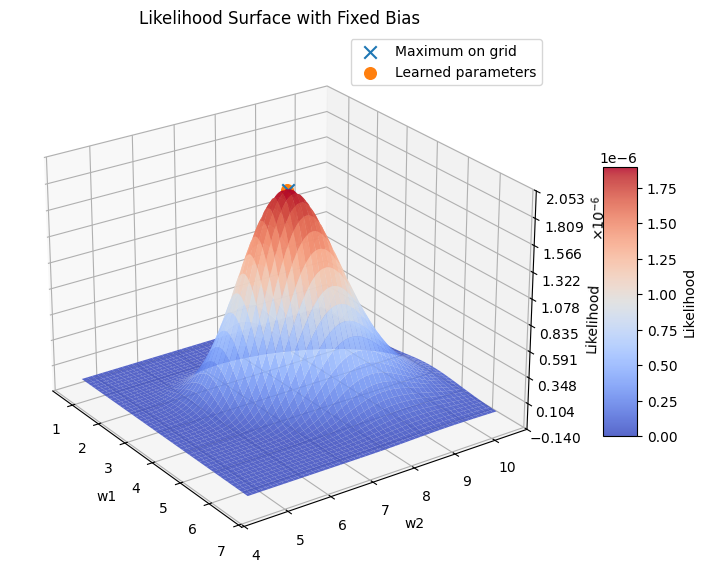

In [25]:
fig11, ax, surf = grad_desc.visualize_surface_3d(
    w1_grid,
    w2_grid,
    likelihood_grid,
    "w1",
    "w2",
    "Likelihood",
    "Likelihood Surface with Fixed Bias",
    colorbar_label="Likelihood",
    view_elev=25,
    view_azim=-35
)
z_formatter = ScalarFormatter(useMathText=True)
ax.zaxis.set_major_formatter(z_formatter)


ax.scatter(
        w1_max,
        w2_max,
        likelihood_max,
        s=80,
        marker="x",
        label="Maximum on grid"
    )

ax.scatter(
    w1_learned,
    w2_learned,
    current_likelihood,
    s=70,
    label="Learned parameters"
)
ax.legend();

## Maximum Likelihood Surface with Fixed Bias

The plot shows a two-dimensional slice through the likelihood landscape of the logistic perceptron. The bias $b$ is kept fixed and is imported from the trained model, while the two weights $w_1$ and $w_2$ are varied.

For each combination of $w_1$ and $w_2$, the model computes new predicted probabilities for all data points. These probabilities are then used to calculate the likelihood of the observed labels.

The highest point on the surface corresponds to the largest likelihood within the displayed parameter grid. This is marked as `Maximum on grid`.

The learned parameters are also shown in the plot. Since they lie very close to the maximum on the grid, this indicates that training moved the parameters toward a region where the observed labels are highly plausible under the model.

It is important to remember that this is only a slice through the full parameter space, because the bias $b$ is fixed in this visualization. The full model depends on $w_1$, $w_2$, and $b$.

The likelihood values are very small, therefore, the absolute height of the surface is less important than the location of its maximum.

## Why Log-Likelihood?

Beside getting very small likelihood values on larger datasets, products are also less convenient to work with than sums.

For this reason, we use the logarithm of the likelihood:

$$
\log L(w,b)
$$

The logarithm turns the product into a sum:

$$
\log L(w,b)
=
\sum_{i=1}^{n}
\log\left(
p_i^{y_i}(1-p_i)^{1-y_i}
\right)
$$

Using the logarithm rules, this becomes:

$$
\log L(w,b)
=
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Since the logarithm is strictly increasing, it does not change the location of the maximum:

$$
\arg\max_{w,b} L(w,b)
=
\arg\max_{w,b} \log L(w,b)
$$

The values change, but the parameter values that maximize the objective remain the same.

In [ ]:
log_likelihood_flat = np.sum(np.log(likelihood_contributions), axis=0)
log_likelihood_grid = log_likelihood_flat.reshape(w1_grid.shape)

max_idx_log = np.unravel_index(
    np.argmax(log_likelihood_grid),
    log_likelihood_grid.shape
)

w1_max = w1_grid[max_idx_log]
w2_max = w2_grid[max_idx_log]
log_likelihood_max = log_likelihood_grid[max_idx_log]

current_log_likelihood = np.log(likelihood_table["P(Observed Label)"]).sum()

print(f"Current log-likelihood: {current_log_likelihood:.4f}")
print(f"Maximum log-likelihood on grid: {log_likelihood_max:.4f}")
print(f"Maximum at w1 = {w1_max:.4f}, w2 = {w2_max:.4f}")
print(f"Learned parameters: w1 = {w1_learned:.4f}, w2 = {w2_learned:.4f} with bias {b_learned:.4f}")

Current log-likelihood: -13.1668
Maximum log-likelihood on grid: -13.1667
Maximum at w1 = 3.6780, w2 = 7.3945
Learned parameters: w1 = 3.6629, w2 = 7.3795 with bias 2.6924


The maximum is still located at `w1 = 3.6629` and `w2 = 7.3795`.

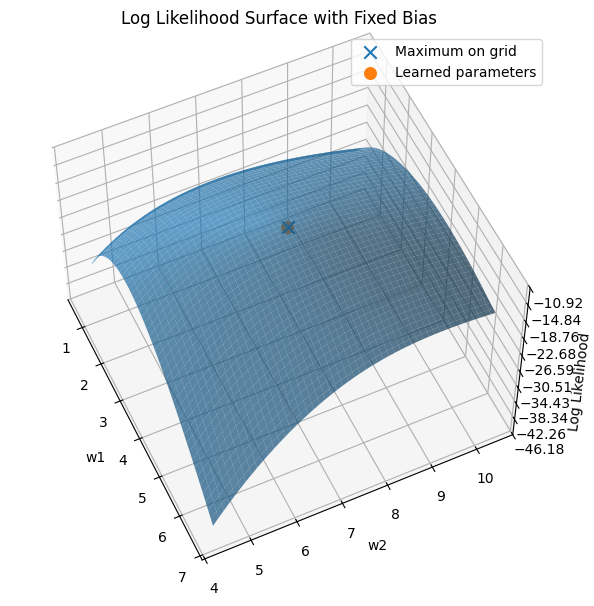

In [27]:
fig12, ax, surf = grad_desc.visualize_surface_3d(
    w1_grid,
    w2_grid,
    log_likelihood_grid,
    "w1",
    "w2",
    "Log Likelihood",
    "Log Likelihood Surface with Fixed Bias",
    cmap=None,
    show_colorbar=None,
    alpha=0.7,
    view_elev=55,
    view_azim=-25
)

ax.scatter(
    w1_max,
    w2_max,
    log_likelihood_max ,
    s=80,
    marker="x",
    label="Maximum on grid"
)

ax.scatter(
    w1_learned,
    w2_learned,
    current_log_likelihood,
    s=70,
    label="Learned parameters"
)
ax.legend();


## Negative Log-Likelihood

The Maximum Likelihood principle is originally a maximization problem. In Machine Learning, and especially in Deep Learning, however, training is usually formulated as the minimization of a loss function.

Backpropagation, the central algorithm that makes efficient training of deep neural networks possible, computes gradients of such an objective function. These gradients are then used by an optimization algorithm to adjust the parameters in the direction of smaller loss values.

More details will follow later in the chapter on **Backpropagation**.

We therefore rewrite the Maximum Likelihood objective as an equivalent minimization problem. To do this, we simply change the sign of the log-likelihood and obtain the **Negative Log-Likelihood**:

$$
\mathrm{NLL}(w,b) = -\log L(w,b)
$$

Maximizing the log-likelihood is therefore equivalent to minimizing the Negative Log-Likelihood:

$$
\max_{w,b} \log L(w,b)
\quad
\Longleftrightarrow
\quad
\min_{w,b} \mathrm{NLL}(w,b)
$$

The location of the optimum remains the same. Only the perspective changes: a quantity that should be made as large as possible becomes a loss function that should be made as small as possible.

In [28]:
negative_log_likelihood_flat = -np.sum(
    np.log(likelihood_contributions),
    axis=0
)

negative_log_likelihood_grid = negative_log_likelihood_flat.reshape(w1_grid.shape)

min_idx_nll = np.unravel_index(
    np.argmin(negative_log_likelihood_grid),
    negative_log_likelihood_grid.shape
)

w1_min = w1_grid[min_idx_nll]
w2_min = w2_grid[min_idx_nll]
negative_log_likelihood_min = negative_log_likelihood_grid[min_idx_nll]

current_negative_log_likelihood = -np.log(
    likelihood_table["P(Observed Label)"]
).sum()

print(f"Current negative log-likelihood: {current_negative_log_likelihood:.4f}")
print(f"Minimum negative log-likelihood on grid: {negative_log_likelihood_min:.4f}")
print(f"Minimum at w1 = {w1_min:.4f}, w2 = {w2_min:.4f}")
print(
    f"Learned parameters: w1 = {w1_learned:.4f}, "
    f"w2 = {w2_learned:.4f} with bias {b_learned:.4f}"
)

Current negative log-likelihood: 13.1668
Minimum negative log-likelihood on grid: 13.1667
Minimum at w1 = 3.6780, w2 = 7.3945
Learned parameters: w1 = 3.6629, w2 = 7.3795 with bias 2.6924


The minimum is still located at `w1 = 3.6629` and `w2 = 7.3795`.

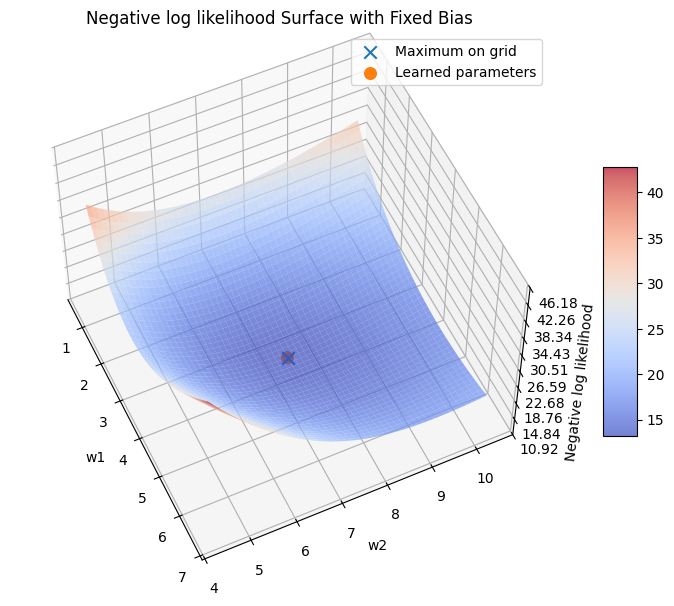

In [29]:
fig13, ax, surf = grad_desc.visualize_surface_3d(
    w1_grid,
    w2_grid,
    negative_log_likelihood_grid,
    "w1",
    "w2",
    "Negative log likelihood",
    "Negative log likelihood Surface with Fixed Bias",
    alpha=0.7,
    view_elev=55,
    view_azim=-25
)

ax.scatter(
    w1_max,
    w2_max,
    negative_log_likelihood_min,
    s=80,
    marker="x",
    label="Maximum on grid"
)

ax.scatter(
    w1_learned,
    w2_learned,
    current_negative_log_likelihood,
    s=70,
    label="Learned parameters"
)

ax.legend();



The Negative Log-Likelihood can be written either as a sum over all data points, as shown here, or as a mean.

For optimization, the factor $\frac{1}{n}$ does not change the location of the optimum, because it only rescales all objective values by the same constant. However, for comparing losses across datasets or training runs, the mean is often used.

## Connecting Negative Log-Likelihood and Binary Cross-Entropy

The Negative Log-Likelihood for the Bernoulli model is:

$$
\mathrm{NLL}(w,b)
=
-
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

If we divide this expression by the number of data points $n$, we obtain the mean Negative Log-Likelihood:

$$
\frac{1}{n}\mathrm{NLL}(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

This expression is exactly the Binary Cross-Entropy over the entire dataset:

$$
\mathrm{BCE}(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Therefore,

$$
\mathrm{BCE}(w,b)
=
\frac{1}{n}\mathrm{NLL}(w,b)
$$

Minimizing mean Binary Cross-Entropy is therefore equivalent to minimizing the mean Negative Log-Likelihood, and thus to maximizing the Bernoulli likelihood of the observed labels.

## Conclusion
Binary Cross-Entropy is therefore not just a practical loss function. Under the Bernoulli assumption, it is exactly the mean Negative Log-Likelihood of the observed labels.

This gives the training of the logistic perceptron an additional statistical interpretation: the parameters are adjusted so that the observed labels become as plausible as possible under the model.

From an information-theoretic perspective, Binary Cross-Entropy can also be understood as a special case of Cross-Entropy between a target distribution and a predicted model distribution. This perspective is not covered in this notebook and will be discussed in a separate chapter.

## Summary: What Does the Logistic Perceptron Do?

The logistic perceptron turns a linear score into a probability:

$$
p_i = \sigma(w^\top x_i+b)
$$

Under the Bernoulli assumption, this probability can be interpreted as

$$
p_i = P(Y=1 \mid X=x_i,w,b).
$$

This gives the model both a geometric and a probabilistic interpretation. Geometrically, the linear score determines the position of a point relative to the decision boundary. Probabilistically, the sigmoid output describes how strongly the model assigns the point to class $1$.

Training with Binary Cross-Entropy can therefore be understood in two equivalent ways:

- as minimizing a loss function,
- or as maximizing the likelihood of the observed labels.

This connects the logistic perceptron to the broader statistical view of probabilistic classification.